In [ ]:
# Install dependencies (run once in Colab)
!pip install earthengine-api geemap

import ee

# Authenticate and initialize Earth Engine
try:
    ee.Initialize(project='your-project-id')
except Exception:
    ee.Authenticate()
    ee.Initialize(project='your-project-id')


In [ ]:
pip install earthengine-api geemap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 39.6 MB/s eta 0:00:00


In [ ]:
!pip install geemap
!pip install earthengine-api


In [ ]:
import geemap


In [ ]:
import ee
ee.Authenticate()
ee.Initialize(project="your-project-id")


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_0JLhFqfSY1uiEaW?source=Init


In [ ]:
pip install numpy rasterio opencv-python scikit-learn matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 62.1 MB/s eta 0:00:00


In [ ]:
import ee
import geemap
from datetime import datetime
import requests
import os

# Authenticate and initialize GEE
try:
    ee.Initialize()
except Exception:
    ee.Authenticate()
    ee.Initialize()

# Define the date range and cloud filter
start_date = '2022-01-01'
end_date = '2022-01-31'
cloud_filter = ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)

def get_sentinel_layer(region):
    # Filter the Sentinel-2 collection
    s2_collection = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterDate(start_date, end_date)
        .filterBounds(region)
        .filter(cloud_filter)
    )

    return s2_collection.mean()  # Return mean image for the selected range

# Initialize map
Map = geemap.Map(center=[17.7009, 83.277], zoom=8)

# Define region
region = ee.Geometry.BBox(80, 15, 86, 20)
sentinel_image = get_sentinel_layer(region)

# Visualization parameters
visualization = {
    'min': 0,
    'max': 3000,
    'bands': ['B4', 'B3', 'B2'],
}

# Add the Sentinel-2 layer and drawing controls
Map.addLayer(sentinel_image.select(['B4', 'B3', 'B2']), visualization, "Sentinel-2 View")
Map.add_draw_control()  # Changed from add_drawing_tools() to add_draw_control()
Map.add_layer_control()

# Display the map
display(Map)

print("Instructions:")
print("1. Use the drawing tools in the left toolbar to draw a rectangle or polygon for your area of interest")
print("2. After drawing, run the download cell below")

# Function to download individual bands
def download_band(image, band_name, region, output_dir):
    try:
        # Select single band and create download URL
        band_image = image.select(band_name)
        url = band_image.getDownloadURL({
            'scale': 10,  # Sentinel-2 native resolution for most bands
            'region': region,
            'format': 'GEO_TIFF',
            'crs': 'EPSG:4326',  # WGS84 coordinate system
            'filePerBand': True
        })

        # Download the file
        response = requests.get(url, stream=True)
        if response.status_code == 200:
            output_file = os.path.join(output_dir, f'sentinel2_{band_name}.tif')
            with open(output_file, 'wb') as f:
                for chunk in response.iter_content(chunk_size=8192):
                    f.write(chunk)
            print(f"Successfully downloaded band {band_name}")
            return True
        else:
            print(f"Failed to download band {band_name}. Status code: {response.status_code}")
            return False

    except Exception as e:
        print(f"Error downloading band {band_name}: {str(e)}")
        return False

Map(center=[17.7009, 83.277], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDat…

Instructions:
1. Use the drawing tools in the left toolbar to draw a rectangle or polygon for your area of interest
2. After drawing, run the download cell below


In [ ]:
import ee
import geemap
from datetime import datetime
import requests
import os
import math

# Function to download individual bands with size check
def download_band(image, band_name, region, output_dir, scale=100):  # Increased default scale to reduce file size
    try:
        # Select single band and create download URL
        band_image = image.select(band_name)

        # Get region bounds
        bounds = region.bounds().getInfo()['coordinates'][0]
        min_x = min(x[0] for x in bounds)
        max_x = max(x[0] for x in bounds)
        min_y = min(x[1] for x in bounds)
        max_y = max(x[1] for x in bounds)

        # Calculate dimensions
        width_deg = max_x - min_x
        height_deg = max_y - min_y

        # Calculate number of pixels
        width_pixels = abs(width_deg * (1000/scale))  # approximate conversion to pixels
        height_pixels = abs(height_deg * (1000/scale))
        total_pixels = width_pixels * height_pixels

        # If the region is too large, split it into tiles
        max_pixels = 25000000  # Safe limit for download

        if total_pixels > max_pixels:
            print(f"Region too large for single download of band {band_name}. Splitting into tiles...")

            # Calculate number of tiles needed
            tiles_needed = math.ceil(total_pixels / max_pixels)
            tiles_per_side = math.ceil(math.sqrt(tiles_needed))

            width_step = width_deg / tiles_per_side
            height_step = height_deg / tiles_per_side

            success = True
            tile_count = 0

            for i in range(tiles_per_side):
                for j in range(tiles_per_side):
                    tile_min_x = min_x + (i * width_step)
                    tile_max_x = min_x + ((i + 1) * width_step)
                    tile_min_y = min_y + (j * height_step)
                    tile_max_y = min_y + ((j + 1) * height_step)

                    tile_geometry = ee.Geometry.Rectangle([tile_min_x, tile_min_y,
                                                         tile_max_x, tile_max_y])

                    url = band_image.getDownloadURL({
                        'scale': scale,
                        'region': tile_geometry,
                        'format': 'GEO_TIFF',
                        'crs': 'EPSG:4326',
                        'filePerBand': True
                    })

                    response = requests.get(url, stream=True)
                    if response.status_code == 200:
                        tile_output_file = os.path.join(output_dir,
                                                      f'sentinel2_{band_name}_tile_{tile_count}.tif')
                        with open(tile_output_file, 'wb') as f:
                            for chunk in response.iter_content(chunk_size=8192):
                                f.write(chunk)
                        print(f"Successfully downloaded tile {tile_count} for band {band_name}")
                        tile_count += 1
                    else:
                        print(f"Failed to download tile {tile_count} for band {band_name}")
                        success = False

            return success

        else:
            # For smaller regions, download as a single file
            url = band_image.getDownloadURL({
                'scale': scale,
                'region': region,
                'format': 'GEO_TIFF',
                'crs': 'EPSG:4326',
                'filePerBand': True
            })

            response = requests.get(url, stream=True)
            if response.status_code == 200:
                output_file = os.path.join(output_dir, f'sentinel2_{band_name}.tif')
                with open(output_file, 'wb') as f:
                    for chunk in response.iter_content(chunk_size=8192):
                        f.write(chunk)
                print(f"Successfully downloaded band {band_name}")
                return True
            else:
                print(f"Failed to download band {band_name}. Status code: {response.status_code}")
                return False

    except Exception as e:
        print(f"Error downloading band {band_name}: {str(e)}")
        return False

def download_sentinel_bands(output_directory='sentinel2_bands', scale=100):
    """
    Download Sentinel-2 bands for the selected region

    Parameters:
    output_directory (str): Directory to save the downloaded files
    scale (int): Resolution in meters (higher values = lower resolution but smaller file size)
                 10 = full resolution
                 20 = half resolution
                 50 = quarter resolution
                 100 = tenth resolution
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_directory, exist_ok=True)

    # Get the drawn geometry
    if not Map.user_roi:
        print("No region selected. Please draw a rectangle or polygon on the map first.")
        return

    # Use the user-drawn region
    selected_region = Map.user_roi

    # Get the Sentinel-2 image for the selected region
    sentinel_image = get_sentinel_layer(selected_region)

    # List of bands to download
    bands_to_download = [
        'B2',  # Blue
        'B3',  # Green
        'B4',  # Red
        'B8',  # NIR
        'B11', # SWIR 1
        'B12'  # SWIR 2
    ]

    # Download each band
    downloaded_bands = []
    for band in bands_to_download:
        success = download_band(sentinel_image, band, selected_region, output_directory, scale=scale)
        if success:
            downloaded_bands.append(band)

    return downloaded_bands

# Run the download with adjusted scale
downloaded_bands = download_sentinel_bands(scale=100)  # Adjust scale as needed (higher number = lower resolution)
if downloaded_bands:
    print(f"\nSuccessfully downloaded bands: {', '.join(downloaded_bands)}")
    print(f"Files are saved in the 'sentinel2_bands' directory")

Successfully downloaded band B2
Successfully downloaded band B3
Successfully downloaded band B4
Successfully downloaded band B8
Successfully downloaded band B11
Successfully downloaded band B12

Successfully downloaded bands: B2, B3, B4, B8, B11, B12
Files are saved in the 'sentinel2_bands' directory



FAI Statistics:
Min FAI: -0.0663
Max FAI: 0.4640
Mean FAI: 0.0369

Cluster Analysis:

Cluster 0:
NIR value: 0.0483
Green/Blue ratio: 0.8410
FAI value: -0.0074
Bloom score: 0.8987

Cluster 1:
NIR value: 0.0329
Green/Blue ratio: 1.1768
FAI value: -0.0257
Bloom score: 1.1748

Cluster 2:
NIR value: 0.0294
Green/Blue ratio: 0.8117
FAI value: -0.0063
Bloom score: 0.8432

Cluster 3:
NIR value: 0.1024
Green/Blue ratio: 0.8967
FAI value: -0.0126
Bloom score: 1.0250


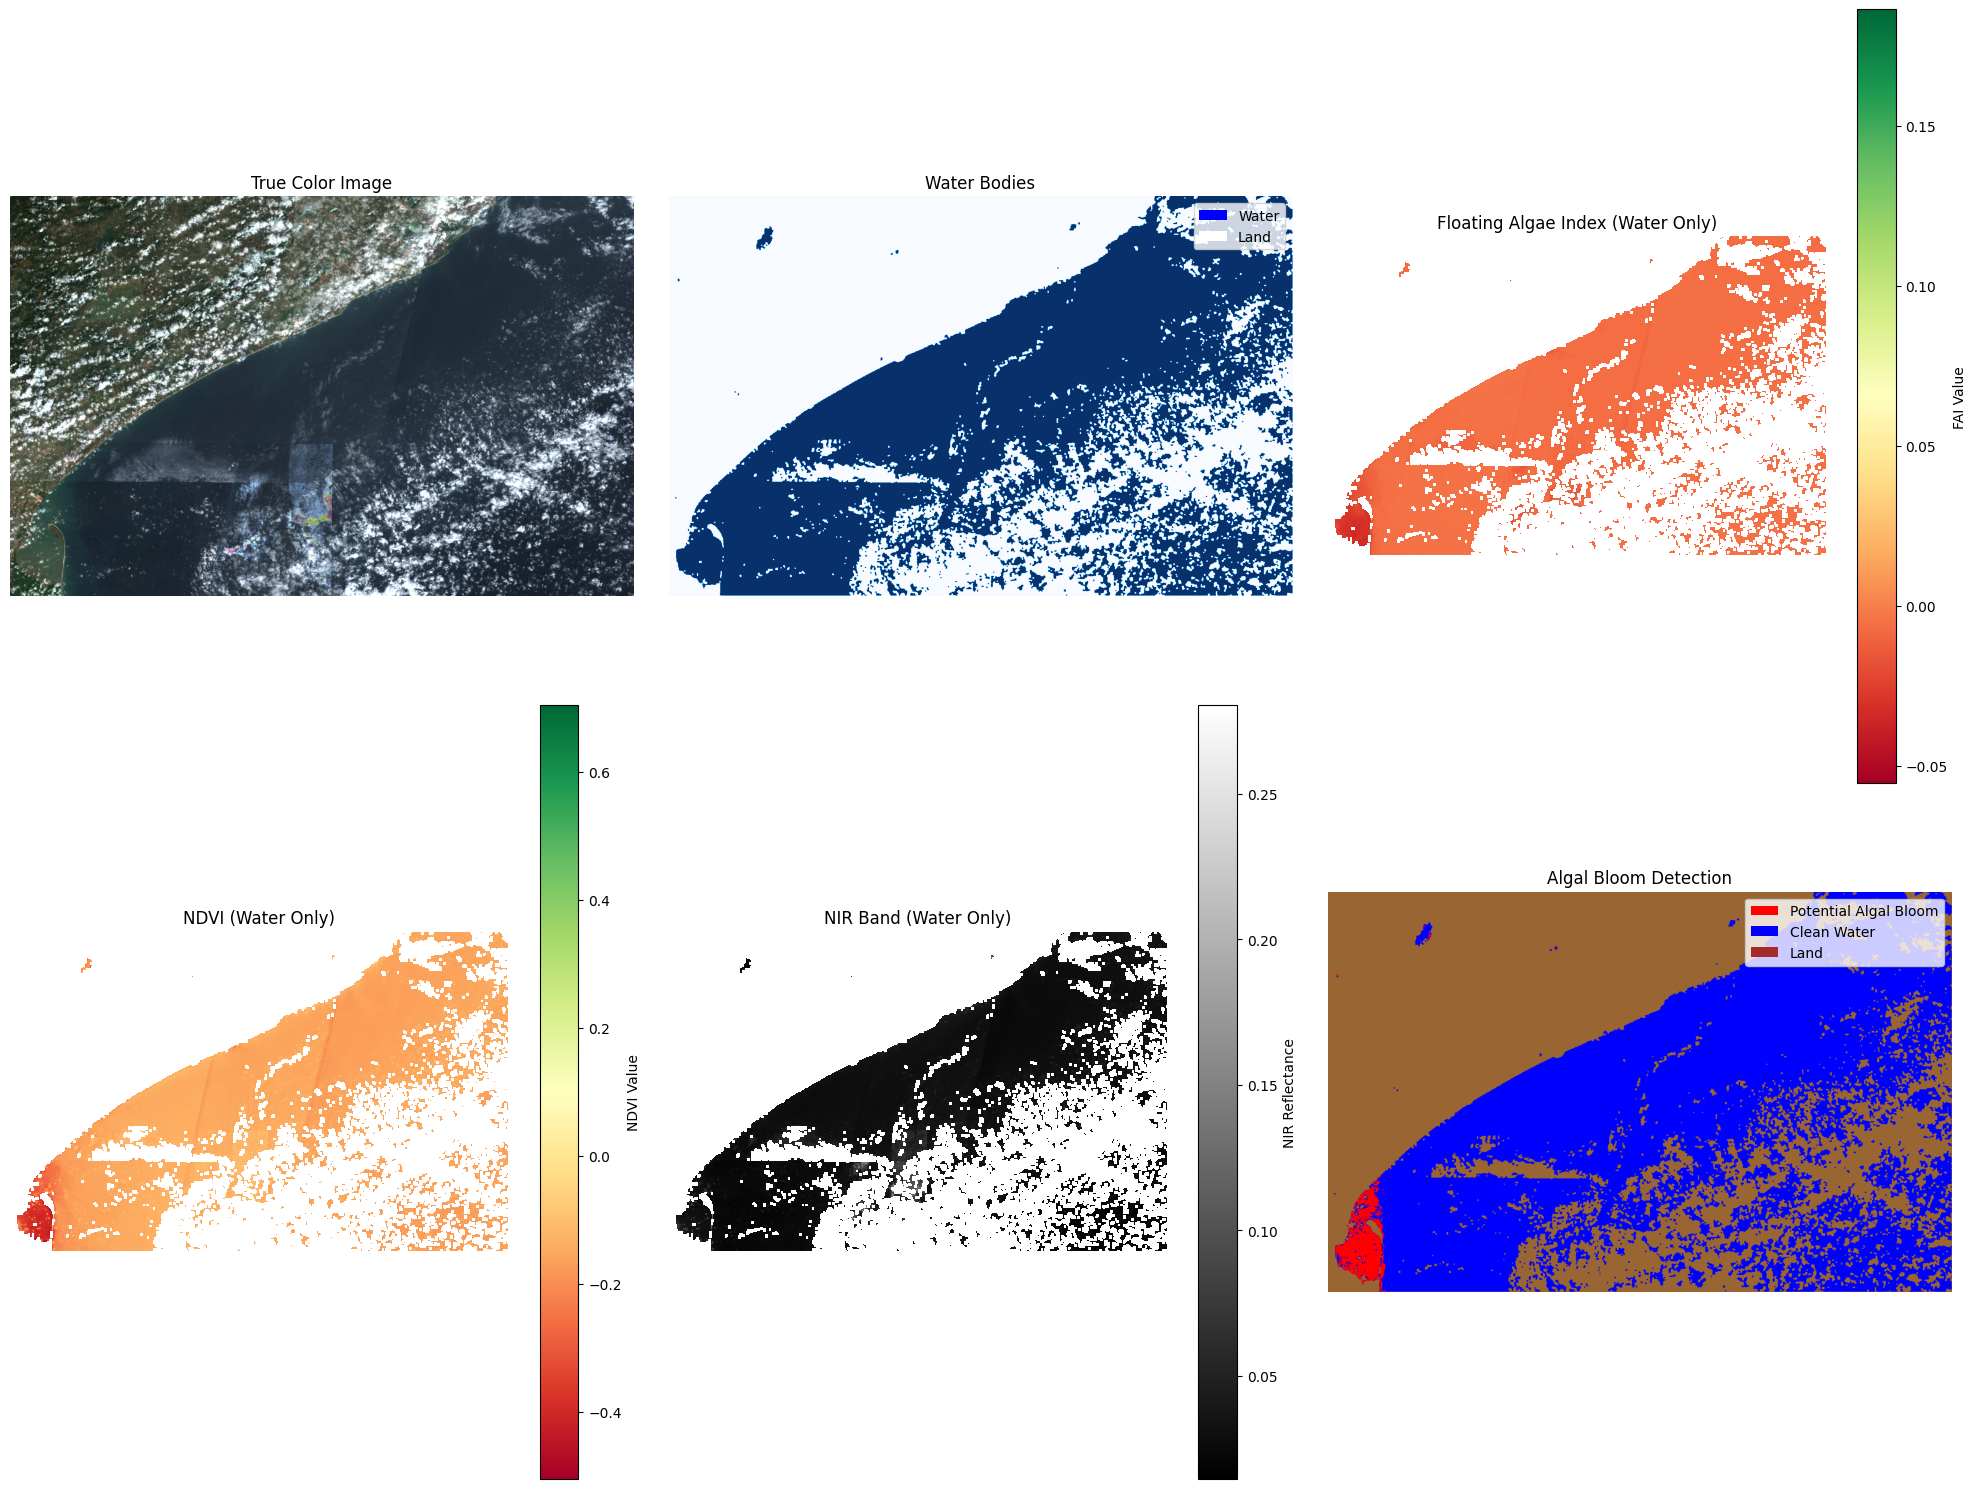

In [ ]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy import ndimage
from matplotlib.patches import Patch

def detect_algal_blooms(input_dir):
    """
    Detect algal blooms in water bodies using Sentinel-2 imagery with corrected FAI calculation.

    Args:
        input_dir (str): Directory containing Sentinel-2 band files
    """
    # Load the required bands
    band_files = {
        'blue': os.path.join(input_dir, 'sentinel2_B2.tif'),
        'green': os.path.join(input_dir, 'sentinel2_B3.tif'),
        'red': os.path.join(input_dir, 'sentinel2_B4.tif'),
        'nir': os.path.join(input_dir, 'sentinel2_B8.tif'),
        'swir': os.path.join(input_dir, 'sentinel2_B11.tif')  # Added SWIR band
    }

    # Sentinel-2 wavelengths in nanometers
    WAVELENGTHS = {
        'red': 665,
        'nir': 842,
        'swir': 1610
    }

    # Read all bands
    bands_data = {}
    for band_name, file_path in band_files.items():
        with rasterio.open(file_path) as src:
            bands_data[band_name] = src.read(1).astype(float)
            bands_data[band_name] = bands_data[band_name] / 10000.0  # Convert to reflectance

    # Calculate indices
    ndwi = (bands_data['green'] - bands_data['nir']) / (bands_data['green'] + bands_data['nir'])

    # Create water mask
    water_mask = ndwi > 0.2
    water_mask = ndimage.binary_opening(water_mask, structure=np.ones((3,3)))
    water_mask = ndimage.binary_closing(water_mask, structure=np.ones((3,3)))

    # Calculate vegetation indices
    ndvi = (bands_data['nir'] - bands_data['red']) / (bands_data['nir'] + bands_data['red'])

    # Calculate FAI (Floating Algae Index) - Corrected formula
    wavelength_ratio = (WAVELENGTHS['nir'] - WAVELENGTHS['red']) / (WAVELENGTHS['swir'] - WAVELENGTHS['red'])
    baseline_nir = bands_data['red'] + (bands_data['swir'] - bands_data['red']) * wavelength_ratio
    fai = bands_data['nir'] - baseline_nir

    # Print diagnostic information
    print("\nFAI Statistics:")
    print(f"Min FAI: {np.nanmin(fai):.4f}")
    print(f"Max FAI: {np.nanmax(fai):.4f}")
    print(f"Mean FAI: {np.nanmean(fai):.4f}")

    # Create feature matrix for water pixels only
    features = np.stack([
        bands_data['blue'],
        bands_data['green'],
        bands_data['red'],
        bands_data['nir'],
        ndvi,
        fai
    ], axis=-1)

    # Mask for water pixels only
    water_pixels = features[water_mask]

    if water_pixels.size > 0:
        # Apply K-means clustering
        n_clusters = 4
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        water_labels = kmeans.fit_predict(water_pixels)

        # Analyze clusters
        cluster_means = kmeans.cluster_centers_

        # Indices for feature array
        nir_idx = 3
        green_idx = 1
        blue_idx = 0
        fai_idx = 5

        # Calculate bloom likelihood scores with FAI contribution
        bloom_scores = (
            cluster_means[:, nir_idx] * 1.5 +      # NIR reflection
            (cluster_means[:, green_idx] / (cluster_means[:, blue_idx] + 1e-6)) * 1.0 +  # Green/Blue ratio
            cluster_means[:, fai_idx] * 2.0        # Increased FAI weight
        )

        # Identify the cluster with highest bloom likelihood
        bloom_cluster = np.argmax(bloom_scores)

        # Create bloom mask
        bloom_mask = np.zeros_like(water_mask, dtype=bool)
        bloom_mask[water_mask] = water_labels == bloom_cluster

        # Print cluster analysis
        print("\nCluster Analysis:")
        for i in range(n_clusters):
            print(f"\nCluster {i}:")
            print(f"NIR value: {cluster_means[i, nir_idx]:.4f}")
            print(f"Green/Blue ratio: {cluster_means[i, green_idx] / (cluster_means[i, blue_idx] + 1e-6):.4f}")
            print(f"FAI value: {cluster_means[i, fai_idx]:.4f}")
            print(f"Bloom score: {bloom_scores[i]:.4f}")
    else:
        bloom_mask = np.zeros_like(water_mask, dtype=bool)

    # Visualization
    fig = plt.figure(figsize=(20, 15))

    # Plot true color image
    true_color = np.stack([
        bands_data['red'],
        bands_data['green'],
        bands_data['blue']
    ], axis=-1)

    # Enhance visualization
    def enhance_image(img, percentile=98):
        top = np.percentile(img, percentile)
        scaled = img / top
        return np.clip(scaled, 0, 1)

    # Plot 1: True Color Image
    ax1 = plt.subplot(231)
    plt.imshow(enhance_image(true_color))
    plt.title('True Color Image')
    plt.axis('off')

    # Plot 2: Water Mask
    ax2 = plt.subplot(232)
    plt.imshow(water_mask, cmap='Blues')
    plt.title('Water Bodies')
    legend_elements_water = [
        Patch(facecolor='blue', label='Water'),
        Patch(facecolor='white', label='Land')
    ]
    ax2.legend(handles=legend_elements_water, loc='upper right')
    plt.axis('off')

    # Plot 3: FAI
    ax3 = plt.subplot(233)
    masked_fai = np.ma.masked_array(fai, ~water_mask)
    plt.imshow(masked_fai, cmap='RdYlGn')
    plt.colorbar(label='FAI Value')
    plt.title('Floating Algae Index (Water Only)')
    plt.axis('off')

    # Plot 4: NDVI
    ax4 = plt.subplot(234)
    masked_ndvi = np.ma.masked_array(ndvi, ~water_mask)
    plt.imshow(masked_ndvi, cmap='RdYlGn')
    plt.colorbar(label='NDVI Value')
    plt.title('NDVI (Water Only)')
    plt.axis('off')

    # Plot 5: NIR Band
    ax5 = plt.subplot(235)
    masked_nir = np.ma.masked_array(bands_data['nir'], ~water_mask)
    plt.imshow(masked_nir, cmap='gray')
    plt.colorbar(label='NIR Reflectance')
    plt.title('NIR Band (Water Only)')
    plt.axis('off')

    # Plot 6: Final Algal Bloom Detection
    ax6 = plt.subplot(236)
    bloom_viz = np.zeros((water_mask.shape[0], water_mask.shape[1], 3))
    bloom_viz[water_mask & ~bloom_mask] = [0, 0, 1]  # Blue for clean water
    bloom_viz[bloom_mask] = [1, 0, 0]  # Red for algal bloom
    bloom_viz[~water_mask] = [0.6, 0.4, 0.2]  # Brown for land

    plt.imshow(bloom_viz)
    plt.title('Algal Bloom Detection')
    legend_elements_bloom = [
        Patch(facecolor='red', label='Potential Algal Bloom'),
        Patch(facecolor='blue', label='Clean Water'),
        Patch(facecolor='brown', label='Land')
    ]
    ax6.legend(handles=legend_elements_bloom, loc='upper right')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    return water_mask, bloom_mask, true_color, fai, ndvi

# Usage
input_dir = 'sentinel2_bands'
water_mask, bloom_mask, true_color, fai, ndvi = detect_algal_blooms(input_dir)

In [ ]:
1